In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
df = pd.read_csv('bangladesh_student_performance_updated.csv')
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
117,29/04/2018,M,19.0,Rural,GT3,Together,4,4,Teacher,Health,No,No,62921.0,5,3.37,2.99
1655,29/04/2018,F,18.0,Urban,GT3,Together,1,1,At_home,Business,No,No,94136.0,5,4.09,3.11
356,29/04/2018,M,17.0,Urban,GT3,Together,3,2,Other,Business,Yes,Yes,81403.0,5,4.43,3.45
54,29/04/2018,F,17.0,Rural,GT3,Apart,1,1,Other,Services,No,No,74075.0,5,2.81,2.00
668,29/04/2018,M,17.0,Rural,LE3,Together,4,2,Teacher,Services,No,Yes,62789.0,3,3.56,3.14
1543,29/04/2018,M,18.0,Rural,LE3,Together,1,1,Health,Health,No,No,45573.0,5,3.38,2.70
76,29/04/2018,F,18.0,Rural,LE3,Together,1,3,At_home,Business,No,No,74900.0,5,3.45,2.93
362,29/04/2018,M,19.0,Rural,GT3,Together,2,2,Other,Health,Yes,No,69370.0,5,4.36,3.25
627,29/04/2018,F,17.0,Urban,GT3,Apart,2,4,Other,Health,Yes,No,79033.0,1,4.35,3.69
1638,29/04/2018,F,17.0,Rural,GT3,Together,0,2,Services,Health,Yes,No,52866.0,1,2.98,2.39


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [192]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [193]:
df.duplicated().sum()

np.int64(0)

In [194]:
df['time_friends'].unique()

array([4, 5, 3, 2, 1])

In [195]:
df['M_Edu'].unique()

array([3, 0, 2, 1, 4])

In [196]:
df.isnull().sum()

,0
date,0
gender,0
age,35
address,35
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,35
F_Job,0


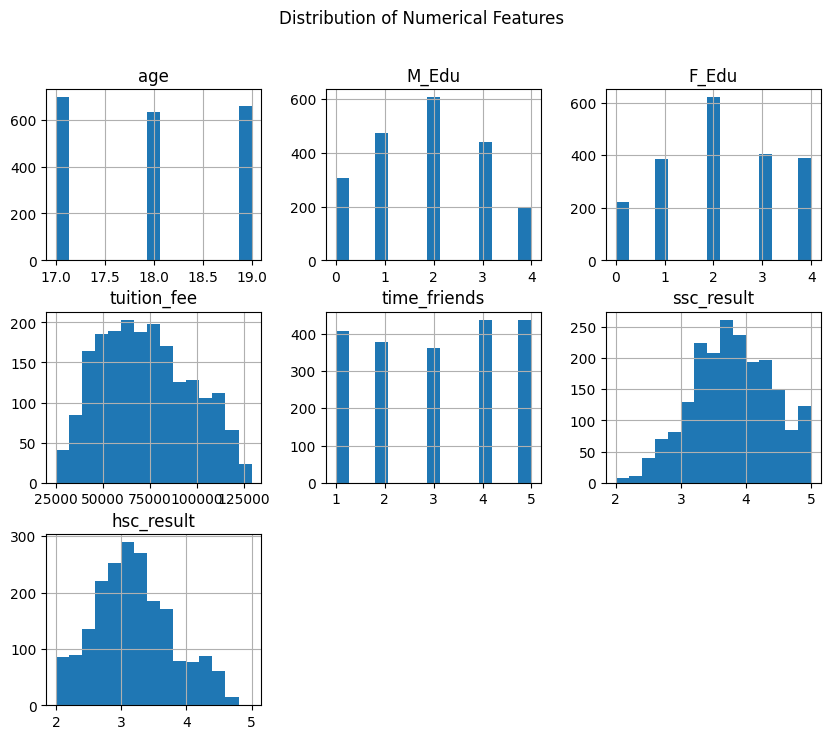

In [197]:
df.hist(bins=15, figsize=(10,8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [198]:
numerical = ['age', 'tuition_fee', 'ssc_result', 'hsc_result']

df[numerical].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


<Axes: >

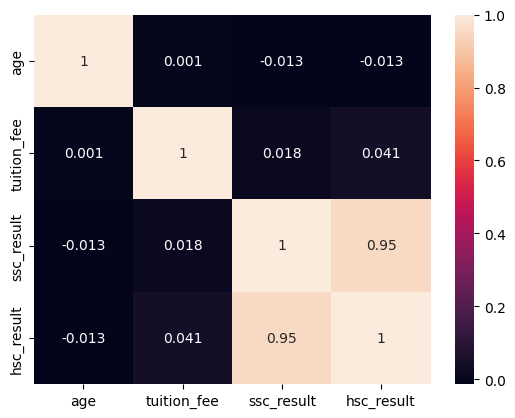

In [199]:
sns.heatmap(df[numerical].corr(), annot=True)

In [200]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline

In [201]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
334,29/04/2018,M,17.0,Rural,GT3,Together,3,3,Teacher,Health,Yes,No,76415.0,1,4.19,3.35
1895,29/04/2018,F,17.0,Rural,GT3,Together,4,2,Services,Farmer,No,No,48097.0,4,2.97,2.69
528,29/04/2018,M,19.0,Urban,GT3,Together,1,0,NaN,Services,Yes,No,89350.0,1,4.45,3.41
1451,29/04/2018,F,19.0,Rural,LE3,Together,2,4,Services,Services,No,No,69407.0,2,4.06,3.72
811,29/04/2018,F,18.0,Rural,GT3,Together,4,3,At_home,Services,Yes,No,58043.0,4,4.21,3.36
1467,29/04/2018,M,19.0,Rural,GT3,Together,3,2,At_home,Services,No,No,72237.0,3,2.88,2.31
190,29/04/2018,M,17.0,Rural,GT3,Together,1,2,Other,Teacher,No,No,30972.0,5,5.00,4.18
738,29/04/2018,M,18.0,Rural,GT3,Together,3,2,Services,Farmer,No,No,63054.0,5,3.46,2.79
187,29/04/2018,F,19.0,Urban,GT3,Together,2,2,Health,Health,No,No,107886.0,4,3.50,3.03
1405,29/04/2018,M,17.0,Rural,GT3,Together,2,3,Health,Health,No,Yes,50106.0,1,2.57,2.29


In [202]:
nominal_cat = ['gender', 'address', 'famsize', 'Pstatus', 'relationship', 'smoker', 'M_Job', 'F_Job']
# ordinal_cat = ['M_Edu', 'F_Edu', 'time_friends']

# M_edu_order = ['0', '1', '2', '3', '4' ]
# F_edu_order = ['0', '1', '2', '3', '4' ]
# time_friends_order = ['5', '4', '3', '2', '1']


numerical_col =['age','tuition_fee', 'ssc_result']




In [203]:
numerical_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

numerical_transformers

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [204]:
nominal_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)

nominal_transformers

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [205]:
ordinal_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[M_edu_order, F_edu_order, time_friends_order])),
        ('scaler', MinMaxScaler())
    ]
)

ordinal_transformers

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(categories=[['0', '1', '2', '3', '4'],
                                            ['0', '1', '2', '3', '4'],
                                            ['5', '4', '3', '2', '1']])),
                ('scaler', MinMaxScaler())])

In [206]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformers, numerical_col),
        ('nominal', nominal_transformers, nominal_cat),
        # ('ordinal', ordinal_transformers, ordinal_cat)
    ],
        remainder='passthrough'
)
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tuition_fee', 'ssc_result']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'address', 'famsize', 'Pstatus',
                                  'relationship', 'smoker', 'M_Job',
                                  'F_Job'])])

In [207]:
X = df.drop(['date', 'hsc_result'], axis=1)
y = df['hsc_result']

In [208]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [209]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1614, 14), (404, 14), (1614,), (404,))

In [210]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17.0,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743.0,1,3.88
526,M,19.0,Rural,GT3,Together,4,3,At_home,Business,No,No,58678.0,5,4.36
393,F,18.0,Urban,GT3,Together,2,1,Services,Services,No,No,115832.0,3,4.47
1789,M,17.0,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781.0,1,4.43
433,M,19.0,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481.0,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17.0,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345.0,4,3.47
693,M,19.0,Urban,GT3,Together,1,2,Health,Business,No,No,85346.0,4,2.96
1494,F,18.0,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638.0,1,3.76
921,M,NaN,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804.0,2,4.18


Linear Regression

In [211]:
from sklearn.linear_model import LinearRegression, SGDRegressor

In [212]:
lr_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)


In [213]:
lr_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'M_Job', 'F_Job'])])),
                ('model', LinearRegression())])

In [214]:
lr_pipe.predict(X_test.head())

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468])

In [215]:
print(y_test.head())

1556    3.19
526     3.70
393     3.82
1789    3.80
433     3.98
Name: hsc_result, dtype: float64


In [216]:
lr_pipe.score(X_test, y_test)

0.945856197606616

SGDRegrassor

In [217]:
sgd_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)


In [218]:
sgd_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'M_Job', 'F_Job'])])),
                ('model', SGDRegressor())])

In [219]:
sgd_pipe.predict(X_test.head())

array([3.22527977, 3.80239528, 3.84790814, 3.94776279, 3.85330221])

In [220]:
y_test.head()

,hsc_result
1556,3.19
526,3.70
393,3.82
1789,3.80
433,3.98


In [221]:
sgd_pipe.score(X_test, y_test)

0.9451444120183373

In [222]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [223]:
# Linear Regression
y_pred = lr_pipe.predict(X_test)
print(f"MSE:{mean_squared_error(y_test, y_pred)}")
print(f"R2:{r2_score(y_test, y_pred)}")
print(f"RMSE:{root_mean_squared_error(y_test, y_pred)}")
print(f"MAE:{mean_absolute_error(y_test, y_pred)}")


MSE:0.02029342621416494
R2:0.945856197606616
RMSE:0.14245499715406595
MAE:0.11143920212478993


In [224]:
# SgdRegreassion
y_pred = sgd_pipe.predict(X_test)
print(f"MSE:{mean_squared_error(y_test, y_pred)}")
print(f"R2:{r2_score(y_test, y_pred)}")
print(f"RMSE:{root_mean_squared_error(y_test, y_pred)}")
print(f"MAE:{mean_absolute_error(y_test, y_pred)}")


MSE:0.02056020777876753
R2:0.9451444120183373
RMSE:0.14338831116505812
MAE:0.11301432852999117
